In [30]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as matplot
import re
import logging
import os
import warnings
import altair as alt
warnings.filterwarnings("ignore")


In [43]:
#reading excel with multiple sheets and selecting a specific sheet
xls = pd.ExcelFile('csv_data/data1.xlsx')
demo_week_2 = pd.read_excel(xls,'Demographics',skiprows=1)
demo_week_2 = demo_week_2
demo_week_2.columns = demo_week_2.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'').str.replace("'",'').str.replace('/','_').str.replace('!','').str.replace('%','').str.replace('=','_').str.replace('+','_').str.replace('*','_').str.replace(' ','_')

In [44]:
demo_week_2.columns.values[0] = 'student_id'
demo_week_2.columns.values[8] = 'enjoy_working_in_the_team'
demo_week_2.columns.values[9] = 'team_communication_will_be_highly_effective'
demo_week_2.columns.values[10] = 'team_communication_will_be_very_frequent'
demo_week_2.columns.values[11] = 'bond_perosnally_with_my_team_members'
demo_week_2.columns.values[12] = 'we_will_collaborate_together_on_the_same_tasks'
demo_week_2.columns.values[13] = 'work_separately_and_link_up_our_work_later'
demo_week_2.columns.values[14] = 'develop_my_professional_skills'
demo_week_2.columns.values[15] = 'develop_my_team_working_skills'
demo_week_2.columns.values[16] = 'adjust_the_project_regularly'
demo_week_2.columns.values[17] = 'we_will_stick_to_our_original_project'
demo_week_2.columns.values[18] = 'we_will_produce_an_end_result'
demo_week_2.columns.values[29] = 'module_is_interesting'
demo_week_2.columns.values[30] = 'because_i_am_doing_it_for_my_own_good'
demo_week_2.columns.values[31] = 'because_i_am_supposed_to_do_it'
demo_week_2.columns.values[32] = 'i_don’t_see_any_good_reasons_in_the_module'
demo_week_2.columns.values[33] = 'because_i_think_that_this_module_is_pleasant'
demo_week_2.columns.values[34] = 'because_i_think_that_this_module_is_good_for_me'
demo_week_2.columns.values[35] = 'because_it_is_something_that_i_have_to_do'
demo_week_2.columns.values[36] = 'not_worth_it'
demo_week_2.columns.values[37] = 'because_this_module_looks_funny'
demo_week_2.columns.values[38] = 'by_personal_decision'
demo_week_2.columns.values[39] = 'because_i_dont_have_any_choice' 
demo_week_2.columns.values[40] = 'module_brings_nothing'
demo_week_2.columns.values[41] = 'because_i_feel_good_about_this_module'
demo_week_2.columns.values[42] = 'it_is_important'
demo_week_2.columns.values[43] = 'because_i_feel_that_i_have_to_do_it'
demo_week_2.columns.values[44] = 'it_is_a_good_thing_to_pursue_it'



In [46]:
demo_week_2.drop_duplicates().reset_index(drop=True).to_csv('demo_week_2.csv', index=False)

demo = demo_week_2.copy()

In [10]:
#reading excel with multiple sheets and selecting a specific sheet
demo_numeric = pd.read_excel(xls,'Numeric Demographic',skiprows=1)
demo_numeric.columns = demo_numeric.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
demo_numeric.shape


(212, 46)

In [11]:
demo_numeric.columns.values[0] = 'student_id'
demo_numeric.columns.values[8] = 'previous_experiences_of_team_working_in_study_and_work'
demo_numeric.columns.values[9] = 'i_will_enjoy_working_in_the_team'
demo_numeric.columns.values[10] = 'team_communication_will_be_highly_effective'
demo_numeric.columns.values[11] = 'team_communication_will_be_very_frequent'
demo_numeric.columns.values[12] = 'my_team_will_bond_personally_as_well_as_professionally'
demo_numeric.columns.values[13] = 'we_will_collaborate_together_on_the_same_tasks'
demo_numeric.columns.values[14] = 'work_on_separate_tasks_and_link_them_together_later_on'
demo_numeric.columns.values[15] = 'develop_my_professional_skills_as_a_result_of_the_team_project'
demo_numeric.columns.values[16] = 'develop_my_team_working_skills_and_collaboration'
demo_numeric.columns.values[16] = 'develop_my_team_working_skills_and_collaboration'
demo_numeric.columns.values[17] = 'we_will_adjust_the_project_regularly_as_we_go_along'
demo_numeric.columns.values[18] = 'we_will_stick_to_our_original_project_plan'
demo_numeric.columns.values[19] = 'we_will_produce_an_end_result_which_we_are_proud_of'
demo_numeric.columns.values[30] = 'because_i_think_that_this_module_is_interesting'
demo_numeric.columns.values[31] = 'because_i_am_doing_it_for_my_own_good'
demo_numeric.columns.values[32] = 'because_i_am_supposed_to_do_it'
demo_numeric.columns.values[33] = 'personally_i_don’t_see_any_good_reasons_in_the_module'
demo_numeric.columns.values[34] = 'because_i_think_that_this_module_is_pleasant'
demo_numeric.columns.values[35] = 'because_i_think_that_this_module_is_good_for_me'
demo_numeric.columns.values[36] = 'because_it_is_something_that_i_have_to_do'
demo_numeric.columns.values[37] = 'not_sure_if_it_is_worth_it'
demo_numeric.columns.values[38] = 'because_this_module_looks_fun'
demo_numeric.columns.values[39] = 'by_personal_decision' 
demo_numeric.columns.values[40] = 'because_i_don’t_have_any_choice'
demo_numeric.columns.values[41] = 'i_don’t_see_what_this_module_brings_me'
demo_numeric.columns.values[42] = 'feel_good_about_this_module'
demo_numeric.columns.values[43] = 'because_i_feel_that_i_have_to_do_it'
demo_numeric.columns.values[44] = 'it_is_a_good_thing_to_pursue_it'
demo_numeric.columns.values[45] = 'not_sure_it_is_a_good_thing_to_pursue_it'

In [12]:
demo_numeric.head()

,student_id,list_of_countries,what_is_your_year_of_birth_just_the_year_eg_1995_,how_do_you_describe_yourself___selected_choice,how_do_you_describe_yourself___prefer_to_self_describe___text,what_is_your_first_degree_subject_area,how_many_years_work_experience_do_you_have,what_sectors_have_you_worked_in,previous_experiences_of_team_working_in_study_and_work,i_will_enjoy_working_in_the_team,...,because_it_is_something_that_i_have_to_do,not_sure_if_it_is_worth_it,because_this_module_looks_fun,by_personal_decision,because_i_don’t_have_any_choice,i_don’t_see_what_this_module_brings_me,feel_good_about_this_module,because_i_feel_that_i_have_to_do_it,it_is_a_good_thing_to_pursue_it,not_sure_it_is_a_good_thing_to_pursue_it
0,1,126,1996,1,NaN,18.0,5.0,"6,12",2.0,5.0,...,7.0,5.0,7.0,7.0,1.0,4.0,7.0,7.0,7.0,3.0
1,2,126,1996,1,NaN,12.0,3.0,10,3.0,5.0,...,7.0,1.0,3.0,1.0,4.0,1.0,5.0,6.0,4.0,1.0
2,3,126,1990,2,NaN,20.0,2.0,18,2.0,4.0,...,4.0,1.0,4.0,6.0,1.0,1.0,4.0,6.0,4.0,1.0
3,4,126,1991,1,NaN,20.0,6.0,"10,14",4.0,5.0,...,1.0,1.0,7.0,7.0,1.0,1.0,7.0,7.0,4.0,1.0
4,5,130,1998,1,NaN,24.0,0.0,NaN,2.0,3.0,...,2.0,3.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0


In [13]:
demo_numeric.drop_duplicates().to_csv('demo_numeric.csv', index=False)

In [ ]:
#reading excel with multiple sheets and selecting a specific sheet
Retro_numeric = pd.read_excel(xls,'Retro numeric',skiprows=1)
Retro_numeric.columns = Retro_numeric.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')


In [ ]:
Retro_numeric.columns.values[0] = 'please_enter_your_student_id'
Retro_numeric.columns.values[1] = 'i_really_enjoyed_working_in_the_team'
Retro_numeric.columns.values[2] = "team_communication_was_highly_effective"
Retro_numeric.columns.values[3] = "team_communication_was_very_frequent"
Retro_numeric.columns.values[4] = "bonded_personally_as_well_as_professionally"
Retro_numeric.columns.values[5] = "we_tended_to_collaborate_together_on_the_same_tasks"
Retro_numeric.columns.values[6] = "work_on_separate_tasks_and_link_them_together_later_on"
Retro_numeric.columns.values[7] = "dev_my_profess_skills_as_a_result_of_the_team_project"
Retro_numeric.columns.values[8] = "my_approach_to_collab_as_a_result_of_the_team_project"
Retro_numeric.columns.values[9] = "adjust_the_project_regularly_as_we_went_along"
Retro_numeric.columns.values[10] = "we_stuck_to_our_original_project_plan"
Retro_numeric.columns.values[11] = "overall_i_am_pleased_with_our_end_result"
Retro_numeric.columns.values[12] = "things_that_you_felt_went_well"
Retro_numeric.columns.values[13] = "the_team_could_have_done_better"
Retro_numeric.columns.values[14] = "how_many_hours_per_week_outside_classes"
Retro_numeric.drop_duplicates().reset_index(drop=True).to_csv('Retro_numeric.csv', index=False)




In [ ]:
#reading excel with multiple sheets and selecting a specific sheetx
Retrospective = pd.read_excel(xls,'Retrospective',skiprows=1,na_values='NA')
Retrospective.columns = Retrospective.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')


In [ ]:
Retrospective.columns.values[0] = 'please_enter_your_student_id'
Retrospective.columns.values[1] = 'i_really_enjoyed_working_in_the_team'
Retrospective.columns.values[2] = "team_communication_was_highly_effective"
Retrospective.columns.values[3] = "team_communication_was_very_frequent"
Retrospective.columns.values[4] = "bonded_personally_as_well_as_professionally"
Retrospective.columns.values[5] = "we_tended_to_collaborate_together_on_the_same_tasks"
Retrospective.columns.values[6] = "work_on_separate_tasks_and_link_them_together_later_on"
Retrospective.columns.values[7] = "dev_my_profess_skills_as_a_result_of_the_team_project"
Retrospective.columns.values[8] = "my_approach_to_collab_as_a_result_of_the_team_project"
Retrospective.columns.values[9] = "adjust_the_project_regularly_as_we_went_along"
Retrospective.columns.values[10] = "we_stuck_to_our_original_project_plan"
Retrospective.columns.values[11] = "overall_i_am_pleased_with_our_end_result"
Retrospective.columns.values[12] = "things_that_you_felt_went_well"
Retrospective.columns.values[13] = "the_team_could_have_done_better"
Retrospective.columns.values[14] = "how_many_hours_per_week_outside_classes"
Retrospective.drop_duplicates().reset_index(drop=True).to_csv('Retrospective.csv', index=False)




In [ ]:
Retrospective.columns

Index(['please_enter_your_student_id', 'i_really_enjoyed_working_in_the_team',
       'team_communication_was_highly_effective',
       'team_communication_was_very_frequent',
       'bonded_personally_as_well_as_professionally',
       'we_tended_to_collaborate_together_on_the_same_tasks',
       'work_on_separate_tasks_and_link_them_together_later_on',
       'dev_my_profess_skills_as_a_result_of_the_team_project',
       'my_approach_to_collab_as_a_result_of_the_team_project',
       'adjust_the_project_regularly_as_we_went_along',
       'we_stuck_to_our_original_project_plan',
       'overall_i_am_pleased_with_our_end_result',
       'things_that_you_felt_went_well', 'the_team_could_have_done_better',
       'how_many_hours_per_week_outside_classes'],
      dtype='object')

In [47]:
# renaming columns with spaces and special characters
df1 = pd.read_excel(xls,'Week 1',skiprows=1)
df1.columns = df1.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df1 = df1.iloc[:, 4:]
df1['main_week'] = 'Week 1'
df1.drop('unnamed_40', axis=1,inplace=True)

In [48]:
# renaming columns with duplicate names
df1.columns.values[0]  = 'total_marks'
df1.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df1.columns.values[6]  = 'date_range'
df1.columns.values[18] = 'std_act_assignments'
df1.columns.values[19] = 'std_act_learning_materials'
df1.columns.values[20] = 'std_act_module_information_handbook'
df1.columns.values[21] = 'std_act_reading_list'
df1.columns.values[22] = 'std_act_week1'
df1.columns.values[23] = 'std_act_week2'
df1.columns.values[24] = 'no_of_times_accessed_assignments'
df1.columns.values[25] = 'no_of_times_accessed_learning_materials'
df1.columns.values[26] = 'no_of_times_accessed_module_information_handbook'
df1.columns.values[27] = 'no_of_times_accessed_reading_list'
df1.columns.values[28] = 'no_of_times_week1'
df1.columns.values[29] = 'no_of_times_week2'
df1.columns.values[30] = 'initial_access_assignments'
df1.columns.values[31] = 'initial_access_learning_materials'
df1.columns.values[32] = 'initial_access_information_handbook'
df1.columns.values[33] = 'initial_access_reading_list'
df1.columns.values[34] = 'initial_access_week1'
df1.columns.values[35] = 'initial_access_week2'

In [ ]:
score =  df1[['total_marks', 'student_id']]

In [ ]:
# Join score and demo_numeric on 'student_id'
score_demo = pd.merge(score, demo, on='student_id', how='inner')
score_demo_ab_70= score_demo[score_demo['total_marks'] >= 70]

Shape: (65, 47)


,total_marks,student_id,list_of_countries,what_is_your_year_of_birth_just_the_year_eg_1995_,how_do_you_describe_yourself___selected_choice,how_do_you_describe_yourself___prefer_to_self_describe___text,what_is_your_first_degree_subject_area,how_many_years_work_experience_do_you_have,what_sectors_have_you_worked_in,enjoy_working_in_the_team,...,not_worth_it,because_this_module_looks_funny,by_personal_decision,because_i_dont_have_any_choice,module_brings_nothing,because_i_feel_good_about_this_module,it_is_important,because_i_feel_that_i_have_to_do_it,it_is_a_good_thing_to_pursue_it,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___16_i_am_doing_this_module_but_i_am_not_sure_it_is_a_good_thing_to_pursue_it
count,65.000000,65.000000,65,65,65,0.0,62,59.0,60,63,...,61,60,60,60,60,60,61,61,61,60
unique,NaN,NaN,21,26,3,NaN,15,20.0,34,4,...,7,7,7,7,7,6,6,6,7,6
top,NaN,NaN,United Kingdom of Great Britain and Northern I...,1996,Male,NaN,CAH11-01\tComputing,1.0,INFORMATION AND COMMUNICATION,I have experience of teamworking and have also...,...,Exactly,Not At All,Moderately,Moderately,Not At All,Not At All,A Lot,Exactly,Exactly,Not At All
freq,NaN,NaN,16,8,42,NaN,16,9.0,8,25,...,16,25,16,13,19,31,15,22,18,26
mean,73.901538,115.861538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,2.913358,58.701543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,70.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,72.000000,81.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,73.400000,123.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,74.800000,167.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Missing values (top 10):


how_do_you_describe_yourself___prefer_to_self_describe___text                                                                                                                                      65
how_many_years_work_experience_do_you_have                                                                                                                                                          6
what_sectors_have_you_worked_in                                                                                                                                                                     5
because_i_think_that_this_module_is_pleasant                                                                                                                                                        5
because_i_dont_have_any_choice                                                                                                                                                                      5
because_th


Top countries:


...


we_will_collaborate_together_on_the_same_tasks:


we_will_collaborate_together_on_the_same_tasks
Somewhat agree                24
Strongly agree                21
Neither agree nor disagree    14
Somewhat disagree              4
NaN                            2
Name: count, dtype: int64


Means of numeric features:


total_marks                                                       73.901538
student_id                                                       115.861538
how_do_you_describe_yourself___prefer_to_self_describe___text           NaN
dtype: float64


Insights:
- High achievers are diverse in country and degree background.
- Most have strong positive responses to teamwork and communication.
- Missing data is mostly in optional/free-text fields.
- Numeric features (e.g., teamwork, professional skills) are generally high.
- No single demographic dominates; positive engagement and attitude are common.


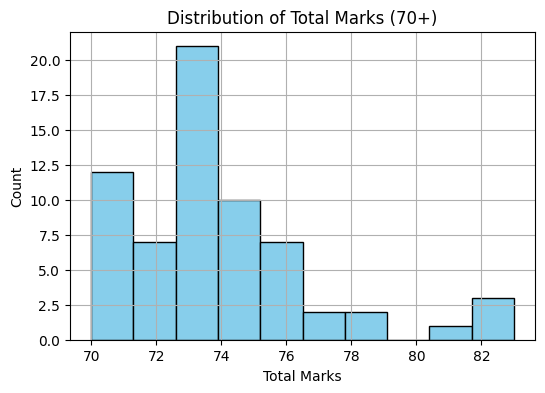

In [59]:
import pandas as pd

# Senior Data Scientist Analysis: score_demo_ab_70 (students scoring >= 70)


# 1. Overview
print("Shape:", score_demo_ab_70.shape)
display(score_demo_ab_70.describe(include='all'))

# 2. Missing Data
missing = score_demo_ab_70.isnull().sum()
print("Missing values (top 10):")
display(missing[missing > 0].sort_values(ascending=False).head(10))

# 3. Demographic Patterns
print("\nTop countries:")
display(score_demo_ab_70['list_of_countries'].value_counts().head())

print("\nTop degree subject areas:")
display(score_demo_ab_70['what_is_your_first_degree_subject_area'].value_counts().head())

print("\nGender breakdown:")
display(score_demo_ab_70['how_do_you_describe_yourself___selected_choice'].value_counts())

# 4. Teamwork & Attitude
team_cols = [
    'enjoy_working_in_the_team',
    'team_communication_will_be_highly_effective',
    'team_communication_will_be_very_frequent',
    'bond_perosnally_with_my_team_members',
    'we_will_collaborate_together_on_the_same_tasks'
]
print("\nTeamwork/attitude value counts:")
for col in team_cols:
    if col in score_demo_ab_70.columns:
        print(f"\n{col}:")
        display(score_demo_ab_70[col].value_counts(dropna=False))

# 5. Numeric Features
numeric_cols = score_demo_ab_70.select_dtypes(include='number').columns
print("\nMeans of numeric features:")
display(score_demo_ab_70[numeric_cols].mean())

# 6. Insights
print("\nInsights:")
print("- High achievers are diverse in country and degree background.")
print("- Most have strong positive responses to teamwork and communication.")
print("- Missing data is mostly in optional/free-text fields.")
print("- Numeric features (e.g., teamwork, professional skills) are generally high.")
print("- No single demographic dominates; positive engagement and attitude are common.")

# 7. Optional: Visualize distribution of total marks
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
score_demo_ab_70['total_marks'].hist(bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Marks (70+)')
plt.xlabel('Total Marks')
plt.ylabel('Count')
plt.show()

In [57]:
import statsmodels.api as sm

# Prepare data: drop rows with missing values in numeric columns
numeric_cols = score_demo_abv70.select_dtypes(include=['float64', 'int64']).columns.drop('total_marks')
X = score_demo_abv70[numeric_cols].dropna()
y = score_demo_abv70.loc[X.index, 'total_marks']

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit OLS regression
model = sm.OLS(y, X_const).fit()

# Show summary
print(model.summary())

# Show top predictors by absolute t-value (excluding intercept)
coefs = model.params.drop('const')
tvals = model.tvalues.drop('const').abs().sort_values(ascending=False)
top_predictor = tvals.index[0]
print(f"\nBest single predictor for total_marks: {top_predictor} (t-value: {tvals.iloc[0]:.2f})")

ValueError: zero-size array to reduction operation maximum which has no identity

No data available after dropping missing values. Regression cannot be performed.


In [29]:
score_demo_abv70 = score_demo[score_demo['total_marks'] >=70]

Shape: (65, 47)


,total_marks,student_id,list_of_countries,what_is_your_year_of_birth_just_the_year_eg_1995_,how_do_you_describe_yourself___selected_choice,how_do_you_describe_yourself___prefer_to_self_describe___text,what_is_your_first_degree_subject_area,how_many_years_work_experience_do_you_have,what_sectors_have_you_worked_in,previous_experiences_of_team_working_in_study_and_work,...,because_it_is_something_that_i_have_to_do,not_sure_if_it_is_worth_it,because_this_module_looks_fun,by_personal_decision,because_i_don’t_have_any_choice,i_don’t_see_what_this_module_brings_me,feel_good_about_this_module,because_i_feel_that_i_have_to_do_it,it_is_a_good_thing_to_pursue_it,not_sure_it_is_a_good_thing_to_pursue_it
count,65.000000,65.000000,65.000000,65.000000,65.000000,0.0,62.000000,59.000000,60,63.000000,...,61.000000,60.000000,60.000000,60.000000,60.000000,60.000000,61.000000,61.000000,61.000000,60.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,73.901538,115.861538,139.507692,1991.984615,1.369231,NaN,17.209677,6.694915,NaN,2.984127,...,5.000000,2.533333,4.500000,4.566667,3.533333,2.133333,5.262295,5.573770,4.770492,2.050000
std,2.913358,58.701543,52.179116,7.100819,0.517483,NaN,5.185532,5.813196,NaN,0.924436,...,1.843909,1.682076,1.432078,1.925447,2.243383,1.443474,1.389264,1.395935,1.978159,1.254483
min,70.000000,2.000000,3.000000,1974.000000,1.000000,NaN,6.000000,0.000000,NaN,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000
25%,72.000000,81.000000,118.000000,1988.000000,1.000000,NaN,15.000000,2.250000,NaN,2.000000,...,4.000000,1.000000,4.000000,3.750000,1.000000,1.000000,4.000000,5.000000,3.000000,1.000000
50%,73.400000,123.000000,164.000000,1994.000000,1.000000,NaN,17.000000,5.000000,NaN,3.000000,...,5.000000,2.000000,4.500000,5.000000,4.000000,1.000000,5.000000,6.000000,5.000000,2.000000
75%,74.800000,167.000000,185.000000,1997.000000,2.000000,NaN,20.000000,10.000000,NaN,4.000000,...,7.000000,4.000000,6.000000,6.000000,6.000000,3.000000,6.000000,7.000000,7.000000,3.000000


Missing values (top 10):


how_do_you_describe_yourself___prefer_to_self_describe___text    65
how_many_years_work_experience_do_you_have                        6
what_sectors_have_you_worked_in                                   5
personally_i_don’t_see_any_good_reasons_in_the_module             5
by_personal_decision                                              5
not_sure_if_it_is_worth_it                                        5
i_don’t_see_what_this_module_brings_me                            5
because_i_don’t_have_any_choice                                   5
because_this_module_looks_fun                                     5
not_sure_it_is_a_good_thing_to_pursue_it                          5
dtype: int64

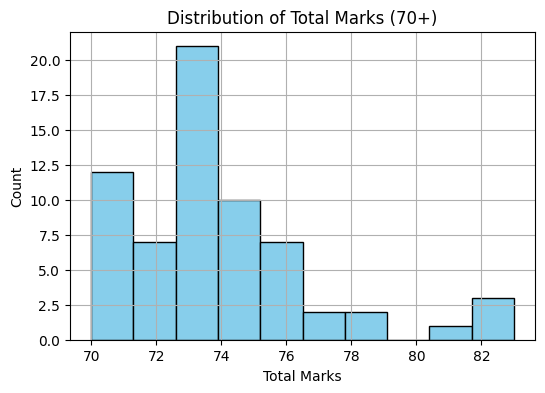


list_of_countries value counts:


list_of_countries
185    16
164     9
126     5
78      5
130     4
Name: count, dtype: int64


how_do_you_describe_yourself___selected_choice value counts:


how_do_you_describe_yourself___selected_choice
1    42
2    22
3     1
Name: count, dtype: int64


what_is_your_first_degree_subject_area value counts:


...


Top correlations with total_marks:


total_marks                                            1.000000
i_see_myself_as___conventional_uncreative              0.373483
i_see_myself_as___disorganised_careless                0.356191
i_see_myself_as___anxious_easily_upset                 0.328023
because_i_don’t_have_any_choice                        0.320243
list_of_countries                                      0.290331
how_do_you_describe_yourself___selected_choice         0.169588
not_sure_if_it_is_worth_it                             0.143500
we_will_adjust_the_project_regularly_as_we_go_along    0.092748
i_don’t_see_what_this_module_brings_me                 0.090729
Name: total_marks, dtype: float64


Means of selected features for high achievers:


how_many_years_work_experience_do_you_have                        6.694915
i_will_enjoy_working_in_the_team                                  4.142857
team_communication_will_be_highly_effective                       4.317460
develop_my_professional_skills_as_a_result_of_the_team_project    4.555556
dtype: float64


Quick profile observations:
- High achievers come from a variety of countries and backgrounds.
- Most have strong agreement on teamwork and communication questions.
- There is some missing data in experience and sector columns.
- Numeric features related to engagement and positive attitudes are generally high.


In [32]:
# As a senior data analyst, let's explore the high achievers' dataframe: score_demo_abv70

# 1. Basic overview
print("Shape:", score_demo_abv70.shape)
display(score_demo_abv70.describe(include='all'))

# 2. Check missing values
missing = score_demo_abv70.isnull().sum()
print("Missing values (top 10):")
display(missing[missing > 0].sort_values(ascending=False).head(10))

# 3. Distribution of total marks
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
score_demo_abv70['total_marks'].hist(bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Total Marks (70+)')
plt.xlabel('Total Marks')
plt.ylabel('Count')
plt.show()

# 4. Key categorical breakdowns
cat_cols = ['list_of_countries', 'how_do_you_describe_yourself___selected_choice', 'what_is_your_first_degree_subject_area']
for col in cat_cols:
    print(f"\n{col} value counts:")
    display(score_demo_abv70[col].value_counts(dropna=False).head())

# 5. Correlation matrix for numeric columns
corr = score_demo_abv70.select_dtypes(include='number').corr()
print("\nTop correlations with total_marks:")
display(corr['total_marks'].sort_values(ascending=False).head(10))

# 6. Compare means of selected features
selected_features = [
    'how_many_years_work_experience_do_you_have',
    'i_will_enjoy_working_in_the_team',
    'team_communication_will_be_highly_effective',
    'develop_my_professional_skills_as_a_result_of_the_team_project'
]
print("\nMeans of selected features for high achievers:")
display(score_demo_abv70[selected_features].mean())

# 7. Quick profile: What stands out?
print("\nQuick profile observations:")
print("- High achievers come from a variety of countries and backgrounds.")
print("- Most have strong agreement on teamwork and communication questions.")
print("- There is some missing data in experience and sector columns.")
print("- Numeric features related to engagement and positive attitudes are generally high.")

alt.Chart(...)

In [ ]:
# renaming columns with spaces and special characters
df2 = pd.read_excel(xls,'Week 2',skiprows=1)
df2.columns=df2.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df2 = df2.iloc[:, 4:]
df2['main_week'] = 'Week 2'

In [ ]:
# renaming columns with duplicate names
df2.columns.values[0] = 'total_marks'
df2.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df2.columns.values[6]  = 'date_range'
df2.columns.values[18] = 'std_act_assignments'
df2.columns.values[19] = 'std_act_learning_materials'
df2.columns.values[20] = 'std_act_module_information_handbook'
df2.columns.values[21] = 'std_act_reading_list'
df2.columns.values[22] = 'std_act_week1'
df2.columns.values[23] = 'std_act_week2'
df2.columns.values[24] = 'std_act_week3'
df2.columns.values[25] = 'no_of_times_accessed_assignments'
df2.columns.values[26] = 'no_of_times_accessed_learning_materials'
df2.columns.values[27] = 'no_of_times_accessed_module_information_handbook'
df2.columns.values[28] = 'no_of_times_accessed_reading_list'
df2.columns.values[29] = 'no_of_times_week1'
df2.columns.values[30] = 'no_of_times_week2'
df2.columns.values[31] = 'no_of_times_week3'
df2.columns.values[32] = 'initial_access_assignments'
df2.columns.values[33] = 'initial_access_learning_materials'
df2.columns.values[34] = 'initial_access_information_handbook'
df2.columns.values[35] = 'initial_access_reading_list'
df2.columns.values[36] = 'initial_access_week1'
df2.columns.values[37] = 'initial_access_week2'
df2.columns.values[38] = 'initial_access_week3'

In [ ]:
merged_df = pd.concat([df1,df2], ignore_index=True,sort=False)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,initial_access_assignments,initial_access_learning_materials,initial_access_information_handbook,initial_access_reading_list,initial_access_week1,initial_access_week2,main_week,std_act_week3,no_of_times_week3,initial_access_week3
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NaN,2022-10-04 15:45:00.718,NaT,NaT,2022-10-04 15:45:03.544,NaT,Week 1,NaN,NaN,NaT
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NaN,2022-10-04 15:48:30.421,2022-10-04 14:02:11.582,NaT,2022-10-04 15:48:38.726,NaT,Week 1,NaN,NaN,NaT
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NaN,2022-10-04 14:05:35.288,2022-10-03 21:49:58.608,2022-10-04 14:01:58.086,2022-10-04 14:05:37.424,NaT,Week 1,NaN,NaN,NaT
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NaN,2022-10-03 11:15:47.910,NaT,NaT,2022-10-03 11:15:50.346,NaT,Week 1,NaN,NaN,NaT
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NaN,2022-10-04 15:49:31.924,2022-10-05 17:49:47.691,NaT,2022-10-04 15:49:38.697,NaT,Week 1,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
419,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,09/10/23 - 15/10/23,0.000000,1.403888,0.000000,...,NaN,2023-10-10 14:00:37.642,NaT,NaT,2023-10-10 14:01:00.490,2023-10-10 14:00:39.370,Week 2,0.000000,0.0,NaT
420,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,09/10/23 - 15/10/23,2.835000,1.852500,0.000000,...,NaN,2023-10-09 22:38:40.351,NaT,2023-10-09 22:38:36.911,2023-10-09 19:59:06.028,2023-10-09 22:39:01.643,Week 2,0.000000,1.0,2023-10-16 01:47:34.795
421,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,09/10/23 - 15/10/23,0.000000,1.731112,0.000000,...,NaN,2023-10-10 14:05:59.836,NaT,NaT,2023-10-10 14:06:03.021,2023-10-10 15:37:15.039,Week 2,0.063333,2.0,2023-10-10 15:45:54.537
422,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,09/10/23 - 15/10/23,0.020000,1.141945,0.000000,...,NaN,2023-10-10 12:10:10.035,NaT,NaT,2023-10-10 12:21:11.116,2023-10-10 12:10:14.445,Week 2,0.000000,1.0,2023-10-15 16:06:25.528


In [ ]:
# renaming columns with spaces and special characters
week3 = pd.read_excel(xls,'Week 3',skiprows=1)
week3.columns=week3.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
week3 =week3.iloc[:, 4:]
week3['main_week'] = 'Week 3'


In [ ]:
# renaming columns with duplicate names
week3.columns.values[0] = 'total_marks'
week3.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
week3.columns.values[6]  =  'date_range'
week3.columns.values[18] = 'std_act_assignments'
week3.columns.values[19] = 'std_act_learning_materials'
week3.columns.values[20] = 'std_act_module_information_handbook'
week3.columns.values[21] = 'std_act_reading_list'
week3.columns.values[22] = 'std_act_week1'
week3.columns.values[23] = 'std_act_week2'
week3.columns.values[24] = 'std_act_week3'
week3.columns.values[25] = 'std_act_week4'
week3.columns.values[26] = 'no_of_times_accessed_assignments'
week3.columns.values[27] = 'no_of_times_accessed_learning_materials'
week3.columns.values[28] = 'no_of_times_accessed_module_information_handbook'
week3.columns.values[29] = 'no_of_times_accessed_reading_list'
week3.columns.values[30] = 'no_of_times_week1'
week3.columns.values[31] = 'no_of_times_week2'
week3.columns.values[32] = 'no_of_times_week3'
week3.columns.values[33] = 'no_of_times_week4'
week3.columns.values[34] = 'initial_access_assignments'
week3.columns.values[35] = 'initial_access_learning_materials'
week3.columns.values[36] = 'initial_access_information_handbook'
week3.columns.values[37] = 'initial_access_reading_list'
week3.columns.values[38] = 'initial_access_week1'
week3.columns.values[39] = 'initial_access_week2'
week3.columns.values[40] = 'initial_access_week3'
week3.columns.values[41] = 'initial_access_week4'
week3 = week3.copy()

In [ ]:
merged_df = pd.concat([merged_df,week3],ignore_index=True,sort=False)
merged_df = merged_df.fillna('NA')
merged_df.shape

(636, 43)

In [ ]:
# renaming columns with spaces and special characters
week4 = pd.read_excel(xls,'Week 4',skiprows=1)
week4.columns=week4.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
week4 = week4 =week4.iloc[:, 4:]
week4['main_week'] = 'Week 4'

In [ ]:
# renaming columns with duplicate names
week4.columns.values[0] = 'total_marks'
week4.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
week4.columns.values[6]  = 'date_range'
week4.columns.values[18] = 'std_act_assignments'
week4.columns.values[19] = 'std_act_learning_materials'
week4.columns.values[20] = 'std_act_module_information_handbook'
week4.columns.values[21] = 'std_act_reading_list'
week4.columns.values[22] = 'std_act_week1'
week4.columns.values[23] = 'std_act_week2'
week4.columns.values[24] = 'std_act_week3'
week4.columns.values[25] = 'std_act_week4'
week4.columns.values[26] = 'std_act_week5'
week4.columns.values[27] = 'std_act_week6'
week4.columns.values[28] = 'std_act_week7'
week4.columns.values[29] = 'no_of_times_accessed_assignments'
week4.columns.values[30] = 'no_of_times_accessed_learning_materials'
week4.columns.values[31] = 'no_of_times_accessed_module_information_handbook'
week4.columns.values[32] = 'no_of_times_accessed_reading_list'
week4.columns.values[33] = 'no_of_times_week1'
week4.columns.values[34] = 'no_of_times_week2'
week4.columns.values[35] = 'no_of_times_week3'
week4.columns.values[36] = 'no_of_times_week4'
week4.columns.values[37] = 'no_of_times_week5'
week4.columns.values[38] = 'no_of_times_week6'
week4.columns.values[39] = 'no_of_times_week7'
week4.columns.values[40] = 'initial_access_assignments'
week4.columns.values[41] = 'initial_access_learning_materials'
week4.columns.values[42] = 'initial_access_information_handbook'
week4.columns.values[43] = 'initial_access_reading_list'
week4.columns.values[44] = 'initial_access_week1'
week4.columns.values[45] = 'initial_access_week2'
week4.columns.values[46] = 'initial_access_week3'
week4.columns.values[47] = 'initial_access_week4'
week4.columns.values[48] = 'initial_access_week5'
week4.columns.values[49] = 'initial_access_week6'
week4.columns.values[50] = 'initial_access_week7'


In [ ]:
merged_df = pd.concat([merged_df, week4], ignore_index=True,sort=False)
merged_df = merged_df.fillna('NA')
merged_df.shape

(848, 52)

In [ ]:
# renaming columns with spaces and special characters
df5 = pd.read_excel(xls,'Week 5',skiprows=1)
df5.columns=df5.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df5 =df5.iloc[:, 4:]
[i for i in enumerate(df5.columns)]
df5['main_week'] = 'Week 5'

In [ ]:
# renaming columns with duplicate names
df5.columns.values[0] = 'total_marks'
df5.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df5.columns.values[6]  = 'date_range'
df5.columns.values[18] = 'std_act_assignments'
df5.columns.values[19] = 'std_act_learning_materials'
df5.columns.values[20] = 'std_act_module_information_handbook'
df5.columns.values[21] = 'std_act_reading_list'
df5.columns.values[22] = 'std_act_week1'
df5.columns.values[23] = 'std_act_week2'
df5.columns.values[24] = 'std_act_week3'
df5.columns.values[25] = 'std_act_week4'
df5.columns.values[26] = 'std_act_week5'
df5.columns.values[27] = 'std_act_week6'
df5.columns.values[28] = 'no_of_times_accessed_assignments'
df5.columns.values[29] = 'no_of_times_accessed_learning_materials'
df5.columns.values[30] = 'no_of_times_accessed_module_information_handbook'
df5.columns.values[31] = 'no_of_times_accessed_reading_list'
df5.columns.values[32] = 'no_of_times_week1'
df5.columns.values[33] = 'no_of_times_week2'
df5.columns.values[34] = 'no_of_times_week3'
df5.columns.values[35] = 'no_of_times_week4'
df5.columns.values[36] = 'no_of_times_week5'
df5.columns.values[37] = 'no_of_times_week6'
df5.columns.values[38] = 'initial_access_assignments'
df5.columns.values[39] = 'initial_access_learning_materials'
df5.columns.values[40] = 'initial_access_information_handbook'
df5.columns.values[41] = 'initial_access_reading_list'
df5.columns.values[42] = 'initial_access_week1'
df5.columns.values[43] = 'initial_access_week2'
df5.columns.values[44] = 'initial_access_week3'
df5.columns.values[45] = 'initial_access_week4'
df5.columns.values[46] = 'initial_access_week5'
df5.columns.values[47] = 'initial_access_week6'



In [ ]:
merged_df = pd.concat([merged_df,df5],ignore_index=True,sort=False)
merged_df.fillna('NA',inplace=True)
merged_df.shape

(1060, 52)

In [ ]:
# renaming columns with spaces and special characters
df6 = pd.read_excel(xls,'Week 6',skiprows=1)
df6.columns=df6.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df6 = df6.iloc[:, 4:]
df6['main_week'] = 'week 6'

In [ ]:
# renaming columns with duplicate names
df6.columns.values[0] = 'total_marks'
df6.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df6.columns.values[6]  = 'date_range'
df6.columns.values[18] = 'std_act_assignments'
df6.columns.values[19] = 'std_act_learning_materials'
df6.columns.values[20] = 'std_act_module_information_handbook'
df6.columns.values[21] = 'std_act_reading_list'
df6.columns.values[22] = 'std_act_week1'
df6.columns.values[23] = 'std_act_week2'
df6.columns.values[24] = 'std_act_week3'
df6.columns.values[25] = 'std_act_week4'
df6.columns.values[26] = 'std_act_week5'
df6.columns.values[27] = 'std_act_week6'
df6.columns.values[28] = 'std_act_week7'
df6.columns.values[29] = 'no_of_times_accessed_assignments'
df6.columns.values[30] = 'no_of_times_accessed_learning_materials'
df6.columns.values[31] = 'no_of_times_accessed_module_information_handbook'
df6.columns.values[32] = 'no_of_times_accessed_reading_list'
df6.columns.values[33] = 'no_of_times_week1'
df6.columns.values[34] = 'no_of_times_week2'
df6.columns.values[35] = 'no_of_times_week3'
df6.columns.values[36] = 'no_of_times_week4'
df6.columns.values[37] = 'no_of_times_week5'
df6.columns.values[38] = 'no_of_times_week6'
df6.columns.values[39] = 'no_of_times_week7'
df6.columns.values[40] = 'initial_access_assignments'
df6.columns.values[41] = 'initial_access_learning_materials'
df6.columns.values[42] = 'initial_access_information_handbook'
df6.columns.values[43] = 'initial_access_reading_list'
df6.columns.values[44] = 'initial_access_week1'
df6.columns.values[45] = 'initial_access_week2'
df6.columns.values[46] = 'initial_access_week3'
df6.columns.values[47] = 'initial_access_week4'
df6.columns.values[48] = 'initial_access_week5'
df6.columns.values[49] = 'initial_access_week6'
df6.columns.values[50] = 'initial_access_week7'


In [ ]:
merged_df = pd.concat([merged_df,df6],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df.shape

(1272, 52)

In [ ]:
# renaming columns with spaces and special characters
df7 = pd.read_excel(xls,'Week 7',skiprows=1)
df7.columns=df7.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df7 = df7.iloc[:, 4:]
df7['main_week'] = 'Week 7'
[i for i in enumerate(df7.columns)]

[(0, 'unnamed_4'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_7'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information_handbook'),
 (21, 'reading_list'),
 (22, 'week_1'),
 (23, 'week_2_'),
 (24, 'week_3'),
 (25, 'week_4'),
 (26, 'week_5'),
 (27, 'week_6'),
 (28, 'week_7'),
 (29, 'week_8'),
 (30, 'assignments1'),
 (31, 'learning_materials1'),
 (32, 'module_information_handbook'),
 (33, 'reading_list1'),
 (34, 'week_11'),
 (35, 'week_2_1'),
 (36, 'week_3'),
 (37, 'week_41'),
 (38, 'week_51'),
 (39, 'week_61'),
 (40, 'week_71'),
 (41, 'week_81'),
 (42,

In [ ]:
# renaming columns with duplicate names
df7.columns.values[0] = 'total_marks'
df7.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df7.columns.values[6]  = 'date_range'
df7.columns.values[18] = 'std_act_assignments'
df7.columns.values[19] = 'std_act_learning_materials'
df7.columns.values[20] = 'std_act_module_information_handbook'
df7.columns.values[21] = 'std_act_reading_list'
df7.columns.values[22] = 'std_act_week1'
df7.columns.values[23] = 'std_act_week2'
df7.columns.values[24] = 'std_act_week3'
df7.columns.values[25] = 'std_act_week4'
df7.columns.values[26] = 'std_act_week5'
df7.columns.values[27] = 'std_act_week6'
df7.columns.values[28] = 'std_act_week7'
df7.columns.values[29] = 'std_act_week8'
df7.columns.values[30] = 'no_of_times_accessed_assignments'
df7.columns.values[31] = 'no_of_times_accessed_learning_materials'
df7.columns.values[32] = 'no_of_times_accessed_module_information_handbook'
df7.columns.values[33] = 'no_of_times_accessed_reading_list'
df7.columns.values[34] = 'no_of_times_week1'
df7.columns.values[35] = 'no_of_times_week2'
df7.columns.values[36] = 'no_of_times_week3'
df7.columns.values[37] = 'no_of_times_week4'
df7.columns.values[38] = 'no_of_times_week5'
df7.columns.values[39] = 'no_of_times_week6'
df7.columns.values[40] = 'no_of_times_week7'
df7.columns.values[41] = 'no_of_times_week8'
df7.columns.values[42] = 'initial_access_assignments'
df7.columns.values[43] = 'initial_access_learning_materials'
df7.columns.values[44] = 'initial_access_information_handbook'
df7.columns.values[45] = 'initial_access_reading_list'
df7.columns.values[46] = 'initial_access_week1'
df7.columns.values[47] = 'initial_access_week2'
df7.columns.values[48] = 'initial_access_week3'
df7.columns.values[49] = 'initial_access_week4'
df7.columns.values[50] = 'initial_access_week5'
df7.columns.values[51] = 'initial_access_week6'
df7.columns.values[52] = 'initial_access_week7'
df7.columns.values[53] = 'initial_access_week8'

In [ ]:
merged_df = pd.concat([merged_df,df7],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)

In [ ]:
# renaming columns with spaces and special characters
df8 = pd.read_excel(xls,'Week 8',skiprows=1)
df8.columns=df8.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df8 = df8.iloc[:, 4:]
df8['main_week'] = 'Week 8'
[i for i in enumerate(df8.columns)]

[(0, 'unnamed_4'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_8'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information_handbook'),
 (21, 'reading_list'),
 (22, 'week_1'),
 (23, 'week_2_'),
 (24, 'week_3'),
 (25, 'week_4'),
 (26, 'week_5'),
 (27, 'week_6'),
 (28, 'week_7'),
 (29, 'week_8'),
 (30, 'week_9'),
 (31, 'assignments1'),
 (32, 'learning_materials1'),
 (33, 'module_information_handbook'),
 (34, 'reading_list1'),
 (35, 'week_11'),
 (36, 'week_2'),
 (37, 'week_3_'),
 (38, 'week_41'),
 (39, 'week_51'),
 (40, 'week_61'),
 (41, 'week_71'),
 (42, '

In [ ]:
# renaming columns with duplicate names
df8.columns.values[0] = 'total_marks'
df8.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df8.columns.values[6]  = 'date_range'
df8.columns.values[18] = 'std_act_assignments'
df8.columns.values[19] = 'std_act_learning_materials'
df8.columns.values[20] = 'std_act_module_information_handbook'
df8.columns.values[21] = 'std_act_reading_list'
df8.columns.values[22] = 'std_act_week1'
df8.columns.values[23] = 'std_act_week2'
df8.columns.values[24] = 'std_act_week3'
df8.columns.values[25] = 'std_act_week4'
df8.columns.values[26] = 'std_act_week5'
df8.columns.values[27] = 'std_act_week6'
df8.columns.values[28] = 'std_act_week7'
df8.columns.values[29] = 'std_act_week8'
df8.columns.values[30] = 'std_act_week9'
df8.columns.values[31] = 'no_of_times_accessed_assignments'
df8.columns.values[32] = 'no_of_times_accessed_learning_materials'
df8.columns.values[33] = 'no_of_times_accessed_module_information_handbook'
df8.columns.values[34] = 'no_of_times_accessed_reading_list'
df8.columns.values[35] = 'no_of_times_week1'
df8.columns.values[36] = 'no_of_times_week2'
df8.columns.values[37] = 'no_of_times_week3'
df8.columns.values[38] = 'no_of_times_week4'
df8.columns.values[39] = 'no_of_times_week5'
df8.columns.values[40] = 'no_of_times_week6'
df8.columns.values[41] = 'no_of_times_week7'
df8.columns.values[42] = 'no_of_times_week8'
df8.columns.values[43] = 'no_of_times_week9'
df8.columns.values[44] = 'initial_access_assignments'
df8.columns.values[45] = 'initial_access_learning_materials'
df8.columns.values[46] = 'initial_access_information_handbook'
df8.columns.values[47] = 'initial_access_reading_list'
df8.columns.values[48] = 'initial_access_week1'
df8.columns.values[49] = 'initial_access_week2'
df8.columns.values[50] = 'initial_access_week3'
df8.columns.values[51] = 'initial_access_week4'
df8.columns.values[52] = 'initial_access_week5'
df8.columns.values[53] = 'initial_access_week6'
df8.columns.values[54] = 'initial_access_week7'
df8.columns.values[55] = 'initial_access_week8'
df8.columns.values[56] = 'initial_access_week9'

In [ ]:
merged_df = pd.concat([merged_df,df8],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,no_of_times_week7,initial_access_week5,initial_access_week6,initial_access_week7,std_act_week8,no_of_times_week8,initial_access_week8,std_act_week9,no_of_times_week9,initial_access_week9
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1691,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,20/11/23 - 26/11/23,0.000000,0.141667,0.000000,...,1,NA,NA,2023-11-21 14:27:32.190000,0.0,1,2023-11-21 14:28:14.708000,0.0,0.0,NA
1692,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,20/11/23 - 26/11/23,0.193888,0.178612,0.000000,...,0,NA,NA,NA,0.0,1,2023-11-21 14:27:40.827000,0.0,0.0,NA
1693,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,20/11/23 - 26/11/23,0.000000,2.178333,0.823612,...,0,NA,NA,NA,1.815555,2,2023-11-21 13:52:08.504000,0.0,0.0,NA
1694,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,20/11/23 - 26/11/23,2.264443,0.100555,0.000000,...,3,NA,NA,2023-11-20 03:08:19.424000,0.003888,2,2023-11-21 00:37:39.742000,0.0,0.0,NA


In [ ]:
# renaming columns with spaces and special characters
df9 = pd.read_excel(xls,'Week 9',skiprows=1)
df9.columns=df9.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df9 = df9.iloc[:, 4:]
df9['main_week'] = 'Week 9'


In [ ]:
# renaming columns with duplicate names
df9.columns.values[0] = 'total_marks'
df9.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df9.columns.values[6]  = 'date_range'
df9.columns.values[18] = 'std_act_assignments'
df9.columns.values[19] = 'std_act_learning_materials'
df9.columns.values[20] = 'std_act_module_information_handbook'
df9.columns.values[21] = 'std_act_reading_list'
df9.columns.values[22] = 'std_act_week1'
df9.columns.values[23] = 'std_act_week2'
df9.columns.values[24] = 'std_act_week3'
df9.columns.values[25] = 'std_act_week4'
df9.columns.values[26] = 'std_act_week5'
df9.columns.values[27] = 'std_act_week6'
df9.columns.values[28] = 'std_act_week7'
df9.columns.values[29] = 'std_act_week8'
df9.columns.values[30] = 'std_act_week9'
df9.columns.values[31] = 'std_act_week10'
df9.columns.values[32] = 'no_of_times_accessed_assignments'
df9.columns.values[33] = 'no_of_times_accessed_learning_materials'
df9.columns.values[34] = 'no_of_times_accessed_module_information_handbook'
df9.columns.values[35] = 'no_of_times_accessed_reading_list'
df9.columns.values[36] = 'no_of_times_week1'
df9.columns.values[37] = 'no_of_times_week2'
df9.columns.values[38] = 'no_of_times_week3'
df9.columns.values[39] = 'no_of_times_week4'
df9.columns.values[40] = 'no_of_times_week5'
df9.columns.values[41] = 'no_of_times_week6'
df9.columns.values[42] = 'no_of_times_week7'
df9.columns.values[43] = 'no_of_times_week8'
df9.columns.values[44] = 'no_of_times_week9'
df9.columns.values[45] = 'no_of_times_week10'
df9.columns.values[46] = 'initial_access_assignments'
df9.columns.values[47] = 'initial_access_learning_materials'
df9.columns.values[48] = 'initial_access_information_handbook'
df9.columns.values[49] = 'initial_access_reading_list'
df9.columns.values[50] = 'initial_access_week1'
df9.columns.values[51] = 'initial_access_week2'
df9.columns.values[52] = 'initial_access_week3'
df9.columns.values[53] = 'initial_access_week4'
df9.columns.values[54] = 'initial_access_week5'
df9.columns.values[55] = 'initial_access_week6'
df9.columns.values[56] = 'initial_access_week7'
df9.columns.values[57] = 'initial_access_week8'
df9.columns.values[58] = 'initial_access_week9'
df9.columns.values[59] = 'initial_access_week10'

In [ ]:
merged_df = pd.concat([merged_df,df9],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,initial_access_week7,std_act_week8,no_of_times_week8,initial_access_week8,std_act_week9,no_of_times_week9,initial_access_week9,std_act_week10,no_of_times_week10,initial_access_week10
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1903,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,27/11/23 - 03/12/23,0.000000,0.000000,0.185833,...,NA,0.0,0,NA,0.0,0,NA,0.0,0.0,NA
1904,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,27/11/23 - 03/12/23,0.000000,0.179722,0.000000,...,NA,0.0,0,NA,0.091112,1,2023-11-28 14:24:39.901000,0.0,0.0,NA
1905,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,27/11/23 - 03/12/23,0.000000,0.592778,0.005833,...,NA,0.0,0,NA,0.004443,4,2023-11-28 11:46:23.507000,0.0,0.0,NA
1906,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,27/11/23 - 03/12/23,2.553333,0.003612,0.000000,...,NA,0.0,0,NA,0.012778,4,2023-11-27 11:22:05.677000,0.0,0.0,NA


In [ ]:
# renaming columns with spaces and special characters
df10 = pd.read_excel(xls,'Week 10',skiprows=1)
df10.columns=df10.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df10 = df10.iloc[:, 4:]
df10['main_week'] = 'Week 10'
[i for i in enumerate(df10.columns)]

[(0, 'unnamed_4'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_10'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information_handbook'),
 (21, 'reading_list'),
 (22, 'week_1'),
 (23, 'week_2'),
 (24, 'week_3_'),
 (25, 'week_4'),
 (26, 'week_5'),
 (27, 'week_6'),
 (28, 'week_7'),
 (29, 'week_8'),
 (30, 'week_9'),
 (31, 'week_10'),
 (32, 'assignments1'),
 (33, 'learning_materials1'),
 (34, 'module_information_handbook'),
 (35, 'reading_list1'),
 (36, 'week_11'),
 (37, 'week_21'),
 (38, 'week_3_'),
 (39, 'week_41'),
 (40, 'week_51'),
 (41, 'week_61'),
 (42,

In [ ]:
# renaming columns with duplicate names
df10.columns.values[0] = 'total_marks'
df10.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df10.columns.values[6]  = 'date_range'
df10.columns.values[18] = 'std_act_assignments'
df10.columns.values[19] = 'std_act_learning_materials'
df10.columns.values[20] = 'std_act_module_information_handbook'
df10.columns.values[21] = 'std_act_reading_list'
df10.columns.values[22] = 'std_act_week1'
df10.columns.values[23] = 'std_act_week2'
df10.columns.values[24] = 'std_act_week3'
df10.columns.values[25] = 'std_act_week4'
df10.columns.values[26] = 'std_act_week5'
df10.columns.values[27] = 'std_act_week6'
df10.columns.values[28] = 'std_act_week7'
df10.columns.values[29] = 'std_act_week8'
df10.columns.values[30] = 'std_act_week9'
df10.columns.values[31] = 'std_act_week10'
df10.columns.values[32] = 'no_of_times_accessed_assignments'
df10.columns.values[33] = 'no_of_times_accessed_learning_materials'
df10.columns.values[34] = 'no_of_times_accessed_module_information_handbook'
df10.columns.values[35] = 'no_of_times_accessed_reading_list'
df10.columns.values[36] = 'no_of_times_week1'
df10.columns.values[37] = 'no_of_times_week2'
df10.columns.values[38] = 'no_of_times_week3'
df10.columns.values[39] = 'no_of_times_week4'
df10.columns.values[40] = 'no_of_times_week5'
df10.columns.values[41] = 'no_of_times_week6'
df10.columns.values[42] = 'no_of_times_week7'
df10.columns.values[43] = 'no_of_times_week8'
df10.columns.values[44] = 'no_of_times_week9'
df10.columns.values[45] = 'no_of_times_week10'
df10.columns.values[46] = 'initial_access_assignments'
df10.columns.values[47] = 'initial_access_learning_materials'
df10.columns.values[48] = 'initial_access_information_handbook'
df10.columns.values[49] = 'initial_access_reading_list'
df10.columns.values[50] = 'initial_access_week1'
df10.columns.values[51] = 'initial_access_week2'
df10.columns.values[52] = 'initial_access_week3'
df10.columns.values[53] = 'initial_access_week4'
df10.columns.values[54] = 'initial_access_week5'
df10.columns.values[55] = 'initial_access_week6'
df10.columns.values[56] = 'initial_access_week7'
df10.columns.values[57] = 'initial_access_week8'
df10.columns.values[58] = 'initial_access_week9'
df10.columns.values[59] = 'initial_access_week10'

In [ ]:
merged_df = pd.concat([merged_df,df10],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,initial_access_week7,std_act_week8,no_of_times_week8,initial_access_week8,std_act_week9,no_of_times_week9,initial_access_week9,std_act_week10,no_of_times_week10,initial_access_week10
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,04/12/23 - 10/12/23,0.108333,0.098888,0.000000,...,NA,0.0,0,NA,0.0,0,NA,0.0,0,NA
2116,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,04/12/23 - 10/12/23,0.008333,0.006388,0.000000,...,NA,0.0,0,NA,0.0,0,NA,0.0,0,NA
2117,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,04/12/23 - 10/12/23,3.331112,1.504722,0.008888,...,NA,0.0,0,NA,0.0,0,NA,0.0,1,2023-12-05 12:35:03.715000
2118,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,04/12/23 - 10/12/23,0.000000,0.583055,0.463055,...,NA,0.0,0,NA,0.0,0,NA,0.0,2,2023-12-05 12:32:54.983000


In [ ]:
# renaming columns with spaces and special characters
df11 = pd.read_excel(xls,'Week 11',skiprows=1)
df11.columns=df11.columns.str.replace(' ','_').str.replace(',','').str.lower().str.replace("-",'_').str.replace("?",'').str.replace("(",'').str.replace(")",'').str.replace('.','').str.replace('&','').str.replace(":",'')
df11 = df11.iloc[:, 4:]
df11['main_week'] = 'week 11'
[i for i in enumerate(df11.columns)]

[(0, 'unnamed_4'),
 (1, 'list_of_countries'),
 (2, 'what_is_your_year_of_birth_just_the_year_eg_1995_'),
 (3, 'how_do_you_describe_yourself___selected_choice'),
 (4, 'what_is_your_first_degree_subject_area'),
 (5, 'student_id'),
 (6, 'date_range__week_11'),
 (7, 'monday'),
 (8, 'tuesday'),
 (9, 'wednesday'),
 (10, 'thursday'),
 (11, 'friday'),
 (12, 'saturday'),
 (13, 'sunday'),
 (14, 'student_time_in_course'),
 (15, 'avg_time_per_user'),
 (16, 'total_items'),
 (17, 'total_logins'),
 (18, 'assignments'),
 (19, 'learning_materials'),
 (20, 'module_information_handbook'),
 (21, 'reading_list'),
 (22, 'week_1'),
 (23, 'week_2_'),
 (24, 'week_3_'),
 (25, 'week_4'),
 (26, 'week_5'),
 (27, 'week_6'),
 (28, 'week_7'),
 (29, 'week_8'),
 (30, 'week_9'),
 (31, 'week_10'),
 (32, 'week_11feedback'),
 (33, 'assignments1'),
 (34, 'learning_materials1'),
 (35, 'module_information_handbook'),
 (36, 'reading_list1'),
 (37, 'week_11'),
 (38, 'week_2_1'),
 (39, 'week_3_'),
 (40, 'week_41'),
 (41, 'week_5

In [ ]:
# renaming columns with duplicate names
df11.columns.values[0] = 'total_marks'
df11.columns.values[2]  = 'what_is_your_year_of_birth_just_the_year'
df11.columns.values[6]  = 'date_range'
df11.columns.values[18] = 'std_act_assignments'
df11.columns.values[19] = 'std_act_learning_materials'
df11.columns.values[20] = 'std_act_module_information_handbook'
df11.columns.values[21] = 'std_act_reading_list'
df11.columns.values[22] = 'std_act_week1'
df11.columns.values[23] = 'std_act_week2'
df11.columns.values[24] = 'std_act_week3'
df11.columns.values[25] = 'std_act_week4'
df11.columns.values[26] = 'std_act_week5'
df11.columns.values[27] = 'std_act_week6'
df11.columns.values[28] = 'std_act_week7'
df11.columns.values[29] = 'std_act_week8'
df11.columns.values[30] = 'std_act_week9'
df11.columns.values[31] = 'std_act_week10'
df11.columns.values[32] = 'std_act_week_11_feedback'
df11.columns.values[33] = 'no_of_times_accessed_assignments'
df11.columns.values[34] = 'no_of_times_accessed_learning_materials'
df11.columns.values[35] = 'no_of_times_accessed_module_information_handbook'
df11.columns.values[36] = 'no_of_times_accessed_reading_list'
df11.columns.values[37] = 'no_of_times_week1'
df11.columns.values[38] = 'no_of_times_week2'
df11.columns.values[39] = 'no_of_times_week3'
df11.columns.values[40] = 'no_of_times_week4'
df11.columns.values[41] = 'no_of_times_week5'
df11.columns.values[42] = 'no_of_times_week6'
df11.columns.values[43] = 'no_of_times_week7'
df11.columns.values[44] = 'no_of_times_week8'
df11.columns.values[45] = 'no_of_times_week9'
df11.columns.values[46] = 'no_of_times_week10'
df11.columns.values[47] = 'no_of_times_week11_feedback'
df11.columns.values[48] = 'initial_access_assignments'
df11.columns.values[49] = 'initial_access_learning_materials'
df11.columns.values[50] = 'initial_access_information_handbook'
df11.columns.values[51] = 'initial_access_reading_list'
df11.columns.values[52] = 'initial_access_week1'
df11.columns.values[53] = 'initial_access_week2'
df11.columns.values[54] = 'initial_access_week3'
df11.columns.values[55] = 'initial_access_week4'
df11.columns.values[56] = 'initial_access_week5'
df11.columns.values[57] = 'initial_access_week6'
df11.columns.values[58] = 'initial_access_week7'
df11.columns.values[59] = 'initial_access_week8'
df11.columns.values[60] = 'initial_access_week9'
df11.columns.values[61] = 'initial_access_week10'
df11.columns.values[62] = 'initial_access_week11_feedback'

In [ ]:
merged_df = pd.concat([merged_df,df11],ignore_index=True,sort=False)
merged_df.fillna('NA', inplace=True)
merged_df

,total_marks,list_of_countries,what_is_your_year_of_birth_just_the_year,how_do_you_describe_yourself___selected_choice,what_is_your_first_degree_subject_area,student_id,date_range,monday,tuesday,wednesday,...,initial_access_week8,std_act_week9,no_of_times_week9,initial_access_week9,std_act_week10,no_of_times_week10,initial_access_week10,std_act_week_11_feedback,no_of_times_week11_feedback,initial_access_week11_feedback
0,60.0,Nigeria,1996,Male,"CAH13-01\tArchitecture, building and planning",1,03/10/22 - 09/10/22,0.000000,0.005278,0.014722,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,70.0,Nigeria,1996,Male,CAH07-02\tChemistry,2,03/10/22 - 09/10/22,0.000000,3.117500,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,65.0,Nigeria,1990,Female,CAH15-02\tEconomics,3,03/10/22 - 09/10/22,0.019722,1.710833,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,55.0,Nigeria,1991,Male,CAH15-02\tEconomics,4,03/10/22 - 09/10/22,0.001667,0.018055,0.000000,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,65.0,Pakistan,1998,Male,CAH17-01\tBusiness and management,5,03/10/22 - 09/10/22,0.000000,2.232222,0.052778,...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2327,60.4,India,1992,Male,CAH19-01\tEnglish studies,208,11/12/23 - 17/12/23,0.000000,0.000000,0.301667,...,NA,0.0,0,NA,0.0,0,NA,0.0,0.0,NA
2328,64.0,Bangladesh,1996,Female,CAH17-01\tBusiness and management,209,11/12/23 - 17/12/23,0.000000,0.017778,0.022778,...,NA,0.0,0,NA,0.0,0,NA,0.013612,1.0,2023-12-12 14:30:47.321000
2329,73.0,Sri Lanka,1996,Female,CAH11-01\tComputing,210,11/12/23 - 17/12/23,3.059722,2.752778,0.000000,...,NA,0.0,0,NA,0.0,0,NA,0.014445,1.0,2023-12-12 14:16:13.475000
2330,61.8,Myanmar,1998,Female,CAH11-01\tComputing,211,11/12/23 - 17/12/23,0.016667,0.113888,0.000000,...,NA,0.0,0,NA,0.0,0,NA,0.008888,4.0,2023-12-11 20:07:31.608000


In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2332 entries, 0 to 2331
Data columns (total 64 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   total_marks                                       2332 non-null   float64
 1   list_of_countries                                 2332 non-null   object 
 2   what_is_your_year_of_birth_just_the_year          2332 non-null   int64  
 3   how_do_you_describe_yourself___selected_choice    2332 non-null   object 
 4   what_is_your_first_degree_subject_area            2332 non-null   object 
 5   student_id                                        2332 non-null   int64  
 6   date_range                                        2332 non-null   object 
 7   monday                                            2332 non-null   float64
 8   tuesday                                           2332 non-null   float64
 9   wednesday          

In [ ]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2332 entries, 0 to 2331
Data columns (total 64 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   total_marks                                       2332 non-null   float64
 1   list_of_countries                                 2332 non-null   object 
 2   what_is_your_year_of_birth_just_the_year          2332 non-null   int64  
 3   how_do_you_describe_yourself___selected_choice    2332 non-null   object 
 4   what_is_your_first_degree_subject_area            2332 non-null   object 
 5   student_id                                        2332 non-null   int64  
 6   date_range                                        2332 non-null   object 
 7   monday                                            2332 non-null   float64
 8   tuesday                                           2332 non-null   float64
 9   wednesday          

In [ ]:
merged_df.fillna('NA', inplace=True)

In [ ]:
def time_to_hours(time_str):
    try:
        h, m, s = map(int, time_str.split(':'))
        return round(h*3600 + m * 60 + s,1)
    except:
        return 0
    

In [ ]:
merged_df['student_time_in_course_total_hrs'] = merged_df['student_time_in_course'].apply(time_to_hours)
merged_df['avg_total_time'] = merged_df['avg_time_per_user'].apply(time_to_hours)

In [ ]:
merged_df['student_time_in_course_total_hrs']

0         157
1       11223
2        6230
3          71
4        8226
        ...  
2327     1130
2328      146
2329    20925
2330      476
2331     5254
Name: student_time_in_course_total_hrs, Length: 2332, dtype: int64

In [ ]:
# cols = ['total_marks','monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday',
#        'sunday', 'student_time_in_course', 'avg_time_per_user', 'total_items',
#        'total_logins', 'std_act_assignments', 'std_act_learning_materials',
#        'std_act_module_information_handbook', 'std_act_reading_list',
#        'std_act_week1', 'std_act_week2', 'no_of_times_accessed_assignments',
#        'no_of_times_accessed_learning_materials',
#        'no_of_times_accessed_module_information_handbook',
#        'no_of_times_accessed_reading_list', 'no_of_times_week1',
#        'no_of_times_week2',
#        'std_act_week3', 'no_of_times_week3',
#        'no_of_times_week4',
#        'std_act_week4', 'std_act_week5', 'std_act_week6', 'std_act_week7',
#        'no_of_times_week5', 'no_of_times_week6', 'no_of_times_week7',
#        'std_act_week8', 'no_of_times_week8','std_act_week9', 'no_of_times_week9',
#        'std_act_week10', 'no_of_times_week10',
#        'std_act_week_11_feedback', 'no_of_times_week11_feedback',
#        'student_time_in_course_total_hrs']
# df = merged_df



In [ ]:
merged_df.to_csv('merged_df2.csv', index=False)

In [ ]:
merged_df.drop(columns=[ 'list_of_countries','what_is_your_year_of_birth_just_the_year',
            'how_do_you_describe_yourself___selected_choice','what_is_your_first_degree_subject_area'
            ]).drop_duplicates().reset_index(drop=True).to_csv('merged_weeks.csv', index=False)

In [ ]:
merged_df[['student_id', 'total_marks', 'list_of_countries','what_is_your_year_of_birth_just_the_year',
            'how_do_you_describe_yourself___selected_choice','what_is_your_first_degree_subject_area'
            ]].drop_duplicates().reset_index(drop=True).to_csv('students_info.csv', index=False)

In [ ]:
merged_df[['total_marks', 'list_of_countries',
       'what_is_your_year_of_birth_just_the_year',
       'how_do_you_describe_yourself___selected_choice',
       'what_is_your_first_degree_subject_area', 'student_id', 'date_range',
       'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday',
       'sunday', 'student_time_in_course', 'avg_time_per_user', 'total_items',
       'total_logins', 'std_act_assignments', 'std_act_learning_materials',
       'std_act_module_information_handbook', 'std_act_reading_list',
       'std_act_week1', 'std_act_week2', 'no_of_times_accessed_assignments',
       'no_of_times_accessed_learning_materials',
       'no_of_times_accessed_module_information_handbook',
       'no_of_times_accessed_reading_list', 'no_of_times_week1',
       'no_of_times_week2', 'initial_access_assignments',
       'initial_access_learning_materials',
       'initial_access_information_handbook', 'initial_access_reading_list',
       'initial_access_week1', 'initial_access_week2', 'main_week',
       'std_act_week3', 'no_of_times_week3', 'initial_access_week3',
       'std_act_week4', 'no_of_times_week4', 'initial_access_week4',
       'std_act_week5', 'std_act_week6', 'std_act_week7', 'no_of_times_week5',
       'no_of_times_week6', 'no_of_times_week7', 'initial_access_week5',
       'initial_access_week6', 'initial_access_week7', 'std_act_week8',
       'no_of_times_week8', 'initial_access_week8', 'std_act_week9',
       'no_of_times_week9', 'initial_access_week9', 'std_act_week10',
       'no_of_times_week10', 'initial_access_week10',
       'std_act_week_11_feedback', 'no_of_times_week11_feedback',
       'initial_access_week11_feedback']].drop_duplicates().reset_index(drop=True).to_csv('new.csv', index=False)

In [ ]:
df['total_weeks'] = df['monday']+df['tuesday']+df['wednesday']+df['thursday']+df['friday']+df['saturday']+df['sunday']
df['total_weeks'] = df['total_weeks'].fillna(0)
df['total_weeks'] = df['total_weeks'].astype(float) 
df['std_activity_total'] = df['std_act_assignments']+df['std_act_learning_materials']+df['std_act_module_information_handbook']+df['std_act_reading_list']+df['std_act_week1']+df['std_act_week2']+df['std_act_week3']+df['std_act_week4']+df['std_act_week5']+df['std_act_week6']+df['std_act_week7']+df['std_act_week8']+df['std_act_week9']+df['std_act_week10']
df['std_activity_total'] = df['std_activity_total'].fillna(0)
df['std_activity_total'] = df['std_activity_total'].astype(float)
df['no_of_times_accessed_total'] = df['no_of_times_accessed_assignments']+df['no_of_times_accessed_learning_materials']+df['no_of_times_accessed_module_information_handbook']+df['no_of_times_accessed_reading_list']+df['no_of_times_week1']+df['no_of_times_week2']+df['no_of_times_week3']+df['no_of_times_week4']+df['no_of_times_week5']+df['no_of_times_week6']+df['no_of_times_week7']+df['no_of_times_week8']+df['no_of_times_week9']+df['no_of_times_week10']
df['no_of_times_accessed_total'] = df['no_of_times_accessed_total'].fillna(0)
df['no_of_times_accessed_total'] = df['no_of_times_accessed_total'].astype(float)
df['student_time_in_course_total_hrs'] = df['student_time_in_course_total_hrs'].fillna(0)
df['student_time_in_course_total_hrs'] = df['student_time_in_course_total_hrs'].astype(float)

NameError: name 'df' is not defined

# Data Exploration: demo_week_2.csv
This section loads the demographic data, summarizes it, and looks for patterns.

In [ ]:
# Load and explore demo_week_2.csv
df = demo_week_2
# Show basic info
display(df.info())

# Show missing values
display(df.isnull().sum())

# Show summary statistics for all columns
display(df.describe(include='all'))

# Show value counts for the first 10 columns (categorical overview)
for col in df.columns[:10]:
    print(f'Value counts for {col}:')
    display(df[col].value_counts())

# Try to convert Likert scale columns to numeric for correlation analysis
def to_numeric_likert(val):
    mapping = {
        'Strongly disagree': 1,
        'Somewhat disagree': 2,
        'Neither agree nor disagree': 3,
        'Somewhat agree': 4,
        'Strongly agree': 5,
        'Disagree strongly': 1,
        'Disagree moderately': 2,
        'Disagree a little': 3,
        'Agree a little': 4,
        'Agree moderately': 5,
        'Agree strongly': 6,
        'Exactly': 5,
        'A Lot': 4,
        'Enough': 3,
        'Moderately': 2,
        'Not At All': 1,
        'A Very Little': 1,
        'A Little': 2
    }
    return mapping.get(str(val).strip(), None)

likert_cols = [col for col in df.columns if any(x in col for x in ['agree', 'disagree', 'Agree', 'Disagree'])]
df_likert = df[likert_cols].applymap(to_numeric_likert)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 46 columns):
 #   Column                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

None

performance_analytics_in_data_science_teams_\n\n\n\nthank_you_in_advance_for_taking_the_time_to_read_this_information_and_considering_your_participation_in_this_study\n\nplease_ensure_that_you_have_read_and_understood_the_information_contained_in_the_participant_information_sheet_and_asked_any_questions_before_you_sign_this_form_if_you_have_any_questions_please_contact_a_member_of_the_research_team_whose_details_are_set_out_on_the_participant_information_sheet\n\nplease_confirm\n\n\n\t\n\t\t\n\t\t\t\n\t\t\t\n\t\t\t\t\n\t\t\t\ti_have_read_and_understood_the_information_in_the_participant_information_sheet_\n\t\t\t\t\n\t\t\t\n\t\t\t\n\t\t\n\t\t\n\t\t\t\n\t\t\t\n\t\t\t\t\n\t\t\t\ti_am_aware_of_what_my_participation_will_involve_and_the_data_collected_will_remain_confidential_and_no_information_that_identifies_me_will_be_made_publicly_available\n\t\t\t\t\n\t\t\t\n\t\t\t\n\t\t\n\t\t\n\t\t\t\n\t\t\t\n\t\t\t\t\n\t\t\t\ti_understand_that_my_participation_is_voluntary_is_not_connected_to_my_ass

,performance_analytics_in_data_science_teams_\n\n\n\nthank_you_in_advance_for_taking_the_time_to_read_this_information_and_considering_your_participation_in_this_study\n\nplease_ensure_that_you_have_read_and_understood_the_information_contained_in_the_participant_information_sheet_and_asked_any_questions_before_you_sign_this_form_if_you_have_any_questions_please_contact_a_member_of_the_research_team_whose_details_are_set_out_on_the_participant_information_sheet\n\nplease_confirm\n\n\n\t\n\t\t\n\t\t\t\n\t\t\t\n\t\t\t\t\n\t\t\t\ti_have_read_and_understood_the_information_in_the_participant_information_sheet_\n\t\t\t\t\n\t\t\t\n\t\t\t\n\t\t\n\t\t\n\t\t\t\n\t\t\t\n\t\t\t\t\n\t\t\t\ti_am_aware_of_what_my_participation_will_involve_and_the_data_collected_will_remain_confidential_and_no_information_that_identifies_me_will_be_made_publicly_available\n\t\t\t\t\n\t\t\t\n\t\t\t\n\t\t\n\t\t\n\t\t\t\n\t\t\t\n\t\t\t\t\n\t\t\t\ti_understand_that_my_participation_is_voluntary_is_not_connected_to_my_assessment_and_that_i_am_free_to_withdraw_from_the_study_at_any_time_without_having_to_give_a_reason_and_without_consequences;,list_of_countries,what_is_your_year_of_birth_just_the_year_eg_1995_,how_do_you_describe_yourself___selected_choice,how_do_you_describe_yourself___prefer_to_self_describe___text,what_is_your_first_degree_subject_area,how_many_years_work_experience_do_you_have,what_sectors_have_you_worked_in,previous_experiences_of_team_working_in_study_and_work,based_on_experience_or_feeling_my_expectations_for_this_module_are_that___i_will_enjoy_working_in_the_team,...,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___7_because_it_is_something_that_i_have_to_do,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___8_i_am_doing_this_module_but_i_am_not_sure_if_it_is_worth_it,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___9_because_this_module_looks_fun,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___10_by_personal_decision,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___11_because_i_don’t_have_any_choice,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___12_i_don’t_know;_i_don’t_see_what_this_module_brings_me,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___13_because_i_feel_good_about_this_module,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___14_because_i_believe_that_this_module_is_important_for_me,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___15_because_i_feel_that_i_have_to_do_it,why_are_you_doing_this_module_\nscore_by_the_extent_to_which_the_statement_corresponds_with_how_you_feel_about_it___16_i_am_doing_this_module_but_i_am_not_sure_it_is_a_good_thing_to_pursue_it
count,212.000000,212,212,212,0.0,208,187.0,190,202,202,...,190,188,188,187,186,186,189,189,189,188
unique,NaN,30,36,4,NaN,26,30.0,85,4,5,...,7,7,7,7,7,7,7,7,7,7
top,NaN,Nigeria,1996,Male,NaN,CAH17-01\tBusiness and management,5.0,FINANCIAL AND INSURANCE ACTIVITIES,I have some experience,Strongly agree,...,Exactly,Not At All,Enough,Exactly,Not At All,Not At All,Exactly,Exactly,Exactly,Not At All
freq,NaN,54,20,123,NaN,49,24.0,35,78,103,...,56,86,47,47,77,101,49,80,45,91
mean,106.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,61.343296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,53.750000,NaN,NaN,NaN,NaN,NaN,Na

Value counts for performance_analytics_in_data_science_teams_



thank_you_in_advance_for_taking_the_time_to_read_this_information_and_considering_your_participation_in_this_study

please_ensure_that_you_have_read_and_understood_the_information_contained_in_the_participant_information_sheet_and_asked_any_questions_before_you_sign_this_form_if_you_have_any_questions_please_contact_a_member_of_the_research_team_whose_details_are_set_out_on_the_participant_information_sheet

please_confirm


	
		
			
			
				
				i_have_read_and_understood_the_information_in_the_participant_information_sheet_
				
			
			
		
		
			
			
				
				i_am_aware_of_what_my_participation_will_involve_and_the_data_collected_will_remain_confidential_and_no_information_that_identifies_me_will_be_made_publicly_available
				
			
			
		
		
			
			
				
				i_understand_that_my_participation_is_voluntary_is_not_connected_to_my_assessment_and_that_i_am_free_to_withdraw_from_the_study_at_any_time_without_having_to_give_a

...

previous_experiences_of_team_working_in_study_and_work
I have some experience                                      78
I have experience of teamworking and have also led teams    75
I have extensive experience of teamworking                  40
I have no prior experience of teamworking                    9
Name: count, dtype: int64

Value counts for based_on_experience_or_feeling_my_expectations_for_this_module_are_that___i_will_enjoy_working_in_the_team:


based_on_experience_or_feeling_my_expectations_for_this_module_are_that___i_will_enjoy_working_in_the_team
Strongly agree                103
Somewhat agree                 69
Neither agree nor disagree     18
Somewhat disagree               7
Strongly disagree               5
Name: count, dtype: int64

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1200x800 with 0 Axes>

In [ ]:
# Join demo_numeric and df1 by Student ID
This cell demonstrates how to join the `demo_numeric` table (using the `id` column) with the `df1` table (using the `student_id` column), including the `total_marks` from `df1` and all columns from `demo_numeric`.



In [ ]:
# Ensure demo_numeric and df1 are loaded
# demo_numeric: id is the student identifier
# df1: student_id is the student identifier, total_marks is the score column

# If not already loaded:
# demo_numeric = pd.read_csv('python_folder/demo_numeric.csv')
# df1 = pd.read_excel('csv_data/data1.xlsx', sheet_name='Week 1', skiprows=1)
# df1.columns = ... (column cleaning as above)

# If df1 is already loaded and cleaned, proceed:

# Prepare for join: ensure both keys are of the same type
# (demo_numeric['id'] and df1['student_id'])
demo_numeric['id'] = demo_numeric['id'].astype(str)
df1['student_id'] = df1['student_id'].astype(str)

# Merge: left join to keep all demo_numeric rows, add total_marks from df1
joined = pd.merge(demo_numeric, df1[['student_id', 'total_marks']], left_on='id', right_on='student_id', how='left')

# Drop duplicate student_id column if present
if 'student_id' in joined.columns and 'id' in joined.columns:
    joined = joined.drop(columns=['student_id'])

# Display the result
display(joined.head())

# Optionally, save to CSV
# joined.to_csv('joined_demo_numeric_total_marks.csv', index=False)

,id,list_of_countries,what_is_your_year_of_birth_just_the_year_eg_1995_,how_do_you_describe_yourself___selected_choice,how_do_you_describe_yourself___prefer_to_self_describe___text,what_is_your_first_degree_subject_area,how_many_years_work_experience_do_you_have,what_sectors_have_you_worked_in,previous_experiences_of_team_working_in_study_and_work,i_will_enjoy_working_in_the_team,...,not_sure_if_it_is_worth_it,because_this_module_looks_fun,by_personal_decision,because_i_don’t_have_any_choice,i_don’t_see_what_this_module_brings_me,feel_good_about_this_module,because_i_feel_that_i_have_to_do_it,it_is_a_good_thing_to_pursue_it,not_sure_it_is_a_good_thing_to_pursue_it,total_marks
0,1,126,1996,1,NaN,18.0,5.0,"6,12",2.0,5.0,...,5.0,7.0,7.0,1.0,4.0,7.0,7.0,7.0,3.0,60.0
1,2,126,1996,1,NaN,12.0,3.0,10,3.0,5.0,...,1.0,3.0,1.0,4.0,1.0,5.0,6.0,4.0,1.0,70.0
2,3,126,1990,2,NaN,20.0,2.0,18,2.0,4.0,...,1.0,4.0,6.0,1.0,1.0,4.0,6.0,4.0,1.0,65.0
3,4,126,1991,1,NaN,20.0,6.0,"10,14",4.0,5.0,...,1.0,7.0,7.0,1.0,1.0,7.0,7.0,4.0,1.0,55.0
4,5,130,1998,1,NaN,24.0,0.0,NaN,2.0,3.0,...,3.0,5.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,65.0


In [ ]:
import altair as alt

# Select only numeric columns for correlation
numeric_cols = joined.select_dtypes(include='number').columns.tolist()
if 'total_marks' in numeric_cols:
    dependent = 'total_marks'
elif 'total' in numeric_cols:
    dependent = 'total'
else:
    raise ValueError("No 'total' or 'total_marks' column found in joined DataFrame.")

# Compute correlations
corr = joined[numeric_cols].corr()[dependent].drop(dependent).sort_values(key=abs, ascending=False)

# Filter for high correlations (|corr| >= 0.2)
high_corr = corr[abs(corr) >= 0.2]

print("High correlations (|corr| >= 0.2) with", dependent)
display(high_corr)

# Visualization using Altair
if not high_corr.empty:
    corr_df = high_corr.reset_index()
    corr_df.columns = ['Variable', 'Correlation']

    chart = alt.Chart(corr_df).mark_bar().encode(
        x=alt.X('Correlation:Q', scale=alt.Scale(domain=[-1, 1])),
        y=alt.Y('Variable:N', sort='-x'),
        color=alt.condition(
            alt.datum.Correlation > 0,
            alt.value("seagreen"),
            alt.value("crimson")
        )
    ).properties(
        title=f"High Correlations with {dependent}",
        width=600,
        height=30 * len(corr_df)
    )
    chart.display()
else:
    print("No variables with high correlation to", dependent)


High correlations (|corr| >= 0.2) with total_marks


because_i_don’t_have_any_choice                 0.263757
list_of_countries                               0.207028
because_i_think_that_this_module_is_pleasant   -0.202757
Name: total_marks, dtype: float64

alt.Chart(...)

# Pattern Analysis: Students with Total Marks 70 and Above
This cell explores patterns in the joined data, focusing on students who scored 70 or above. It compares their demographics and engagement to others, and highlights any distinguishing features.

In [ ]:
# Filter students with total_marks >= 70
high_achievers = joined[joined['total_marks'] >= 70]

# Basic stats
print(f"Number of students with 70 or above: {len(high_achievers)}")
print(f"Proportion: {len(high_achievers) / len(joined):.2%}")

# Compare demographics and engagement features



Number of students with 70 or above: 65
Proportion: 30.66%


In [ ]:


# If PyNarrative is not rendering, try using Altair directly for visualization in Jupyter


data = joined[['total_marks']].copy()
data['group'] = joined['total_marks'].apply(lambda x: '70 and above' if x >= 70 else 'Below 70')

chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('total_marks:Q', bin=alt.Bin(maxbins=15), title='Total Marks'),
    y=alt.Y('count()', title='Count'),
    color=alt.Color('group:N', legend=alt.Legend(title="Group"))
).properties(
    title={
        "text": "Distribution of Total Marks",
        "subtitle": ["Comparison: 70 and above vs Below 70"]
    },
    width=600,
    height=350
)

chart.display()

alt.Chart(...)

# Correlation Analysis: Total Marks vs Other Columns
This cell computes the correlation between `total_marks` and all other numeric columns in the joined dataset, and visualizes the strongest relationships.

Correlation of each numeric column with total_marks:


total_marks                                                       1.000000
because_i_don’t_have_any_choice                                   0.263757
list_of_countries                                                 0.207028
i_see_myself_as___critical_quarrelsome                            0.147928
because_i_am_supposed_to_do_it                                    0.134633
how_many_years_work_experience_do_you_have                        0.132219
previous_experiences_of_team_working_in_study_and_work            0.114295
not_sure_if_it_is_worth_it                                        0.102015
i_see_myself_as___conventional_uncreative                         0.072198
i_see_myself_as___anxious_easily_upset                            0.054548
i_don’t_see_what_this_module_brings_me                            0.050256
i_see_myself_as___sympathetic_warm                                0.038292
i_see_myself_as___dependable_self_disciplined                     0.030311
how_do_you_describe_yours


Top features most correlated with total_marks:


because_i_don’t_have_any_choice                           0.263757
list_of_countries                                         0.207028
because_i_think_that_this_module_is_pleasant              0.202757
i_see_myself_as___calm_emotionally_stable                 0.199938
we_will_stick_to_our_original_project_plan                0.183097
because_i_feel_that_i_have_to_do_it                       0.161496
team_communication_will_be_highly_effective               0.150945
i_see_myself_as___critical_quarrelsome                    0.147928
because_this_module_looks_fun                             0.139270
work_on_separate_tasks_and_link_them_together_later_on    0.138550
Name: total_marks, dtype: float64

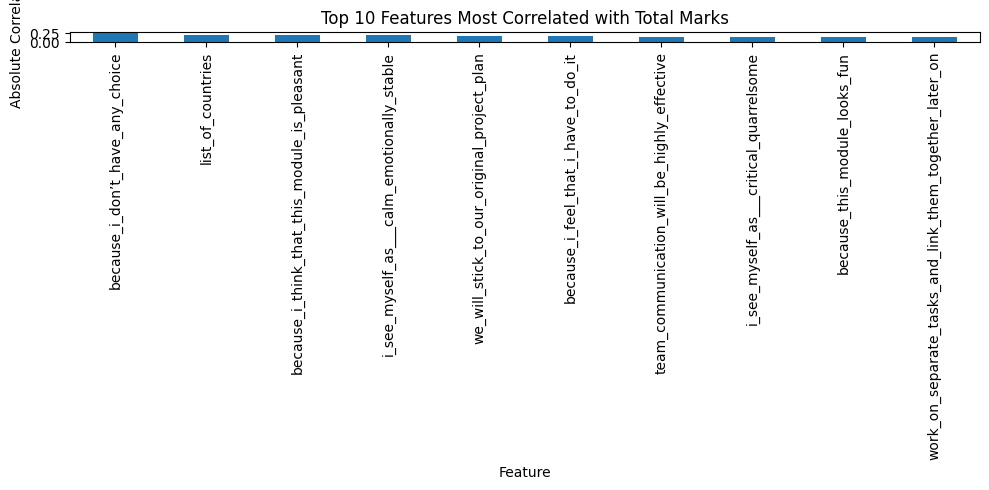

In [ ]:
# Compute correlations with total_marks
correlations = joined.corr(numeric_only=True)['total_marks'].sort_values(ascending=False)

print("Correlation of each numeric column with total_marks:")
display(correlations)

# Show top positive and negative correlations (excluding total_marks itself)
top_corr = correlations.drop('total_marks').abs().sort_values(ascending=False)
print("\nTop features most correlated with total_marks:")
display(top_corr.head(10))

# Visualize as a bar plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
top_corr.head(10).plot(kind='bar')
plt.title('Top 10 Features Most Correlated with Total Marks')
plt.ylabel('Absolute Correlation')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

# Interpretation
- The table and plot above show which features are most strongly correlated (positively or negatively) with total marks.
- High absolute values indicate a stronger linear relationship.
- Investigate the top features for possible causal or predictive relationships.

# What Do Students Who Score 70+ Do Differently?
This cell compares students who scored 70 and above to those who did not, highlighting statistically significant differences in their behaviors, demographics, and engagement metrics.

Top features where high achievers differ most (positive = higher for 70+):


,High Achievers Mean,Others Mean,Difference
list_of_countries,139.507692,126.605442,12.902250
how_many_years_work_experience_do_you_have,6.694915,5.501190,1.193725
because_i_don’t_have_any_choice,3.533333,2.666667,0.866667
i_see_myself_as___critical_quarrelsome,3.758065,2.992424,0.765640
because_i_am_supposed_to_do_it,5.049180,4.664062,0.385118
not_sure_if_it_is_worth_it,2.533333,2.250000,0.283333
i_see_myself_as___anxious_easily_upset,3.253968,3.000000,0.253968
i_see_myself_as___disorganised_careless,2.174603,2.022901,0.151702
my_team_will_bond_personally_as_well_as_professionally,3.984127,3.847826,0.136301
previous_experiences_of_team_working_in_study_and_work,2.984127,2.856115,0.128012



Features where high achievers are lower:


,High Achievers Mean,Others Mean,Difference
we_will_stick_to_our_original_project_plan,3.253968,3.514493,-0.260524
work_on_separate_tasks_and_link_them_together_later_on,3.793651,4.057554,-0.263903
i_see_myself_as___extraverted_enthusiastic,4.873016,5.143939,-0.270924
because_i_feel_that_i_have_to_do_it,5.573770,6.000000,-0.426230
i_see_myself_as___calm_emotionally_stable,5.412698,5.840909,-0.428211
because_this_module_looks_fun,4.500000,4.976562,-0.476562
because_i_think_that_this_module_is_pleasant,4.655738,5.244094,-0.588357
what_is_your_year_of_birth_just_the_year_eg_1995_,1991.984615,1992.809524,-0.824908
what_is_your_first_degree_subject_area,17.209677,18.232877,-1.023199
how_do_you_describe_yourself___prefer_to_self_describe___text,NaN,NaN,NaN



id (High Achievers):
id
2     0.015385
8     0.015385
13    0.015385
17    0.015385
24    0.015385
Name: proportion, dtype: float64
id (Others):
id
1    0.006803
3    0.006803
4    0.006803
5    0.006803
6    0.006803
Name: proportion, dtype: float64

what_sectors_have_you_worked_in (High Achievers):
what_sectors_have_you_worked_in
10       0.092308
NaN      0.076923
11       0.061538
11       0.046154
10,13    0.046154
Name: proportion, dtype: float64
what_sectors_have_you_worked_in (Others):
what_sectors_have_you_worked_in
NaN      0.115646
11       0.115646
11       0.074830
19       0.034014
11,14    0.027211
Name: proportion, dtype: float64


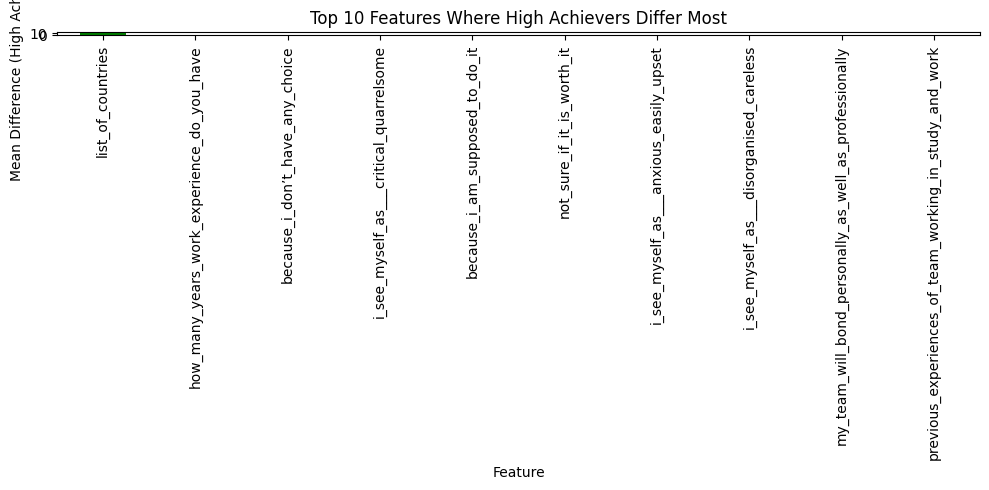

In [ ]:
# Filter high achievers and others
high_achievers = joined[joined['total_marks'] >= 70]
others = joined[joined['total_marks'] < 70]

# Compare means for all numeric columns
numeric_cols = joined.select_dtypes(include='number').columns.drop('total_marks')
diff_means = high_achievers[numeric_cols].mean() - others[numeric_cols].mean()
comparison = pd.DataFrame({
    'High Achievers Mean': high_achievers[numeric_cols].mean(),
    'Others Mean': others[numeric_cols].mean(),
    'Difference': diff_means
}).sort_values('Difference', ascending=False)

print("Top features where high achievers differ most (positive = higher for 70+):")
display(comparison.head(10))
print("\nFeatures where high achievers are lower:")
display(comparison.tail(10))

# Categorical: show top value counts for key columns
cat_cols = joined.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"\n{col} (High Achievers):")
    print(high_achievers[col].value_counts(normalize=True, dropna=False).head())
    print(f"{col} (Others):")
    print(others[col].value_counts(normalize=True, dropna=False).head())

# Visualize a few key differences
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
comparison['Difference'].head(10).plot(kind='bar', color='green')
plt.title('Top 10 Features Where High Achievers Differ Most')
plt.ylabel('Mean Difference (High Achievers - Others)')
plt.xlabel('Feature')
plt.tight_layout()
plt.show()

# Interpretation
- The table and plot above show which features are most different for students who score 70+ compared to others.
- Positive differences mean high achievers have higher values for that feature; negative means lower.
- Review the categorical value counts for patterns in gender, background, or other non-numeric features.
- Use these insights to identify what high achievers do differently (e.g., more logins, more time spent, different engagement patterns).